In [1]:
from lcdb.db import LCDB
from lcdb.analysis import LearningCurveExtractor
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#datasets = [3,12,23,31,54]

In [3]:


lcdb = LCDB()

df_full = lcdb.query(
    workflows=["lcdb.workflow.sklearn.LibLinearWorkflow"],
    campaigns=['probing-pre1k-pp'],
    # openmlids=datasets,
    return_generator=False,
    processors={
        "learning_curve": LearningCurveExtractor(
            metrics=["error_rate"],
            folds=["val"]
        )
    },
    show_progress=True
)

100%|██████████| 5/5 [00:16<00:00,  3.33s/it]


In [4]:
datasets = df_full['m:openmlid'].unique()

In [5]:
dataset_to_analyze = datasets[4]

In [6]:
from lcdb.analysis import merge_curves

df_valid = df_full[df_full["learning_curve"].notnull()]
df_1dataset = df_valid[df_valid['m:openmlid'] == dataset_to_analyze]
config_cols = [c for c in df_1dataset.columns if c.startswith("p:")]


In [7]:
df_1dataset.columns

Index(['p:C', 'p:class_weight', 'p:dual', 'p:fit_intercept',
       'p:intercept_scaling', 'p:loss', 'p:max_iter', 'p:multi_class',
       'p:penalty', 'p:pp@cat_encoder', 'p:pp@decomposition',
       'p:pp@featuregen', 'p:pp@featureselector', 'p:pp@scaler', 'p:tol',
       'p:pp@kernel_pca_kernel', 'p:pp@kernel_pca_n_components',
       'p:pp@poly_degree', 'p:pp@selectp_percentile', 'p:pp@std_with_std',
       'objective', 'job_id', 'job_status', 'm:timestamp_submit',
       'm:lcdb_version', 'm:campaign', 'm:openmlid', 'm:workflow_seed',
       'm:workflow', 'm:valid_prop', 'm:test_prop', 'm:monotonic',
       'm:valid_seed', 'm:test_seed', 'm:timestamp_start', 'm:timestamp_end',
       'm:memory', 'm:build_issues', 'm:timestamp_gather', 'has_result',
       'learning_curve'],
      dtype='object')

In [8]:
import pandas as pd

df = df_1dataset

learner_cols = [col for col in df.columns if col.startswith('p:') and not col.startswith('p:pp@')]
preproc_cols = [col for col in df.columns if col.startswith('p:pp@')]

# Find the most common learner configuration
default_learner = (
    df[learner_cols]
    .value_counts()
    .idxmax()
)

# Find the most common preprocessor configuration
default_preproc = (
    df[preproc_cols]
    .value_counts()
    .idxmax()
)

# Convert to Series for nice formatting
default_learner_series = pd.Series(default_learner, index=learner_cols)
default_preproc_series = pd.Series(default_preproc, index=preproc_cols)

# Print results
print("Default Learner Hyperparameters:")
print(default_learner_series)

print("\nDefault Preprocessor Hyperparameters:")
print(default_preproc_series)

Default Learner Hyperparameters:
p:C                              1.0
p:class_weight                  none
p:dual                          True
p:fit_intercept                 True
p:intercept_scaling              1.0
p:loss                 squared_hinge
p:max_iter                      1000
p:multi_class                    ovr
p:penalty                         l2
p:tol                          0.001
dtype: object

Default Preprocessor Hyperparameters:
p:pp@cat_encoder                  none
p:pp@decomposition                none
p:pp@featuregen                   none
p:pp@featureselector              none
p:pp@scaler                       none
p:pp@kernel_pca_kernel          linear
p:pp@kernel_pca_n_components      0.01
p:pp@poly_degree                     2
p:pp@selectp_percentile              1
p:pp@std_with_std                 True
dtype: object


In [9]:
df.loc[:, 'uses_default_learner'] = (df[learner_cols] == default_learner_series).all(axis=1).astype(int)
df.loc[:, 'uses_default_preprocessor'] = (df[preproc_cols] == default_preproc_series).all(axis=1).astype(int)


/tmp/ipykernel_28617/2150566276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'uses_default_learner'] = (df[learner_cols] == default_learner_series).all(axis=1).astype(int)
/tmp/ipykernel_28617/2150566276.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'uses_default_preprocessor'] = (df[preproc_cols] == default_preproc_series).all(axis=1).astype(int)


In [10]:
print("\nDefault usage combinations (counts):")
print(df[['uses_default_learner', 'uses_default_preprocessor']].value_counts().sort_index())


Default usage combinations (counts):
uses_default_learner  uses_default_preprocessor
0                     0                            333
                      1                            333
1                     0                            332
                      1                              2
Name: count, dtype: int64


In [11]:
config_cols.append('uses_default_learner')
config_cols.append('uses_default_preprocessor')

In [12]:
df.columns

Index(['p:C', 'p:class_weight', 'p:dual', 'p:fit_intercept',
       'p:intercept_scaling', 'p:loss', 'p:max_iter', 'p:multi_class',
       'p:penalty', 'p:pp@cat_encoder', 'p:pp@decomposition',
       'p:pp@featuregen', 'p:pp@featureselector', 'p:pp@scaler', 'p:tol',
       'p:pp@kernel_pca_kernel', 'p:pp@kernel_pca_n_components',
       'p:pp@poly_degree', 'p:pp@selectp_percentile', 'p:pp@std_with_std',
       'objective', 'job_id', 'job_status', 'm:timestamp_submit',
       'm:lcdb_version', 'm:campaign', 'm:openmlid', 'm:workflow_seed',
       'm:workflow', 'm:valid_prop', 'm:test_prop', 'm:monotonic',
       'm:valid_seed', 'm:test_seed', 'm:timestamp_start', 'm:timestamp_end',
       'm:memory', 'm:build_issues', 'm:timestamp_gather', 'has_result',
       'learning_curve', 'uses_default_learner', 'uses_default_preprocessor'],
      dtype='object')

In [13]:
df_grouped = df.groupby(config_cols).agg({"learning_curve": merge_curves})

In [14]:
config_cols

['p:C',
 'p:class_weight',
 'p:dual',
 'p:fit_intercept',
 'p:intercept_scaling',
 'p:loss',
 'p:max_iter',
 'p:multi_class',
 'p:penalty',
 'p:pp@cat_encoder',
 'p:pp@decomposition',
 'p:pp@featuregen',
 'p:pp@featureselector',
 'p:pp@scaler',
 'p:tol',
 'p:pp@kernel_pca_kernel',
 'p:pp@kernel_pca_n_components',
 'p:pp@poly_degree',
 'p:pp@selectp_percentile',
 'p:pp@std_with_std',
 'uses_default_learner',
 'uses_default_preprocessor']

In [15]:
default_learner_list = []
default_preprocessor_list = []

for G in df.groupby(config_cols):
    uses_default_learner = G[0][-1]
    uses_default_preprocessor = G[0][-2]

    default_learner_list.append(uses_default_learner)
    default_preprocessor_list.append(uses_default_preprocessor)



In [16]:
from lcdb.analysis import LearningCurveGroup
lcg = LearningCurveGroup(df_grouped["learning_curve"])

# 


Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 800]/None
Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 800]/None
Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 800]/None
Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 800]/None
Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 800]/None
Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 800]/None
Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningC

In [ ]:
len(lcg)

938

In [18]:
lc_list = []
for lc in lcg:
      lc_list.append(lc)

lcs = np.concatenate(lc_list)

In [19]:
lcs2 = np.squeeze(lcs)
lcs2.shape

(938, 13)

In [20]:
default_learner = np.array(default_learner_list)
default_preprocessor = np.array(default_preprocessor_list)

In [21]:
lcs2[default_learner==1, :]

# how many rows are all nans?


array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [22]:
default_both = (default_learner & default_preprocessor)

In [23]:
default_either = (default_learner | default_preprocessor)
no_default = default_either == 0

In [24]:
learner_default_count = np.sum(default_learner)
preprocessor_default_count = np.sum(default_preprocessor)
both_default_count = np.sum(default_both)
no_default_count = np.sum(no_default)

# print it nicely:
print(f"Default Learner count: {learner_default_count}")
print(f"Default Preprocessor count: {preprocessor_default_count}")
print(f"Both Default count: {both_default_count}")
print(f"No Default count: {no_default_count}")



Default Learner count: 334
Default Preprocessor count: 272
Both Default count: 1
No Default count: 333


In [25]:
import numpy as np

# Default Learner group
learner_rows = lcs2[default_learner == 1, :]
learner_default_count = learner_rows.shape[0]
learner_nan_count = np.isnan(learner_rows).all(axis=1).sum()

# Default Preprocessor group
preprocessor_rows = lcs2[default_preprocessor == 1, :]
preprocessor_default_count = preprocessor_rows.shape[0]
preprocessor_nan_count = np.isnan(preprocessor_rows).all(axis=1).sum()

# Both Default group
both_rows = lcs2[default_both == 1, :]
both_default_count = both_rows.shape[0]
both_nan_count = np.isnan(both_rows).all(axis=1).sum()

# No Default group
no_default_rows = lcs2[no_default == 1, :]
no_default_count = no_default_rows.shape[0]
no_nan_count = np.isnan(no_default_rows).all(axis=1).sum()

# Print summary
print(f"OpenML ID: {dataset_to_analyze}")
print(f"Default Learner count: {learner_default_count} (NaN curves: {learner_nan_count})")
print(f"Default Preprocessor count: {preprocessor_default_count} (NaN curves: {preprocessor_nan_count})")
print(f"Both Default count: {both_default_count} (NaN curves: {both_nan_count})")
print(f"No Default count: {no_default_count} (NaN curves: {no_nan_count})")


OpenML ID: 31
Default Learner count: 334 (NaN curves: 334)
Default Preprocessor count: 272 (NaN curves: 270)
Both Default count: 1 (NaN curves: 1)
No Default count: 333 (NaN curves: 333)


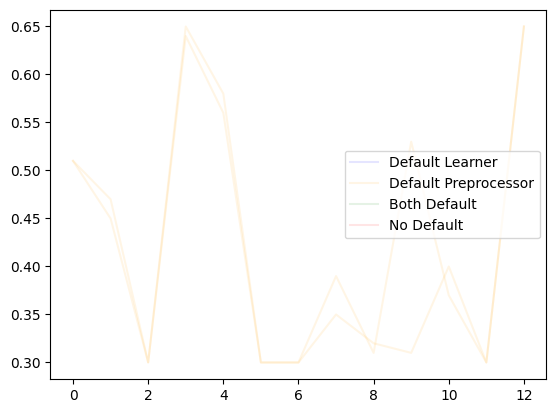

In [26]:
alpha = 0.1

# Plot Default Learner group
for i, row in enumerate(lcs2[default_learner==1, :]):
    plt.plot(row.T, color='blue', alpha=alpha, label='Default Learner' if i == 0 else "")

# Plot Default Preprocessor group
for i, row in enumerate(lcs2[default_preprocessor==1, :]):
    plt.plot(row.T, color='orange', alpha=alpha, label='Default Preprocessor' if i == 0 else "")

# Plot Both Default group
for i, row in enumerate(lcs2[default_both, :]):
    plt.plot(row.T, color='green', alpha=alpha, label='Both Default' if i == 0 else "")

# Plot No Default group
for i, row in enumerate(lcs2[no_default, :]):
    plt.plot(row.T, color='red', alpha=alpha, label='No Default' if i == 0 else "")

plt.legend()
plt.show()

In [27]:
lcs2[default_both, :]

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

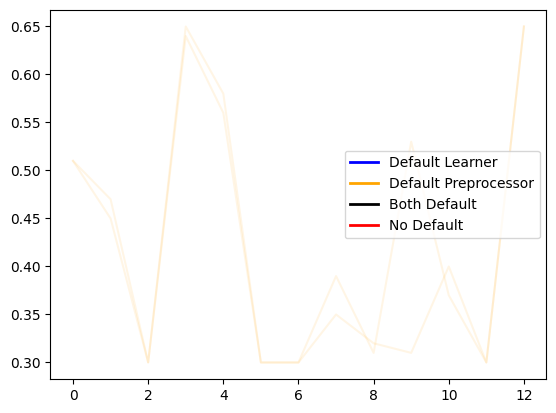

In [28]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

alpha = 0.1

# Plot Default Learner group
for row in lcs2[default_learner == 1, :]:
    plt.plot(row.T, color='blue', alpha=alpha)

# Plot Default Preprocessor group
for row in lcs2[default_preprocessor == 1, :]:
    plt.plot(row.T, color='orange', alpha=alpha)

# Plot No Default group
for row in lcs2[no_default == 1, :]:
    plt.plot(row.T, color='red', alpha=alpha)

# Plot Both Default group
for row in lcs2[default_both == 1, :]:
    plt.plot(row.T, color='black')

# Create opaque legend handles
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Default Learner'),
    Line2D([0], [0], color='orange', lw=2, label='Default Preprocessor'),
    Line2D([0], [0], color='black', lw=2, label='Both Default'),
    Line2D([0], [0], color='red', lw=2, label='No Default')
]

plt.legend(handles=legend_elements)
plt.show()


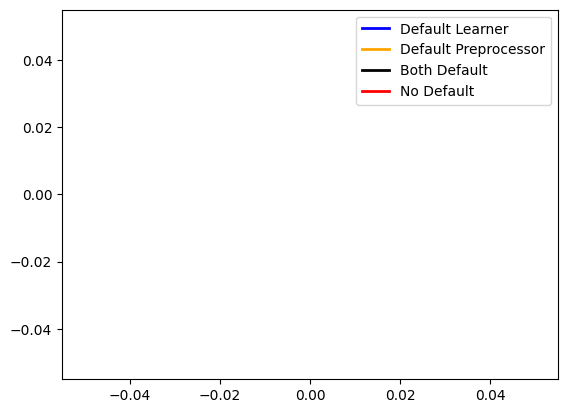

In [29]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

alpha = 0.1

# Plot Default Learner group
for row in lcs2[default_learner == 1, :]:
    plt.plot(row.T, color='blue', alpha=alpha)

# Plot Default Preprocessor group
#for row in lcs2[default_preprocessor == 1, :]:
#    plt.plot(row.T, color='orange', alpha=alpha)

# Plot No Default group
#for row in lcs2[no_default == 1, :]:
#    plt.plot(row.T, color='red', alpha=alpha)

# Plot Both Default group
for row in lcs2[default_both == 1, :]:
    plt.plot(row.T, color='black')

# Create opaque legend handles
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Default Learner'),
    Line2D([0], [0], color='orange', lw=2, label='Default Preprocessor'),
    Line2D([0], [0], color='black', lw=2, label='Both Default'),
    Line2D([0], [0], color='red', lw=2, label='No Default')
]

plt.legend(handles=legend_elements)
plt.show()


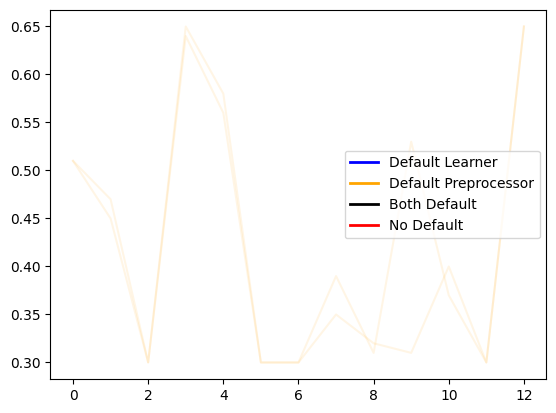

In [30]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

alpha = 0.1

# Plot Default Learner group
#for row in lcs2[default_learner == 1, :]:
#    plt.plot(row.T, color='blue', alpha=alpha)

# Plot Default Preprocessor group
for row in lcs2[default_preprocessor == 1, :]:
    plt.plot(row.T, color='orange', alpha=alpha)

# Plot No Default group
#for row in lcs2[no_default == 1, :]:
#    plt.plot(row.T, color='red', alpha=alpha)

# Plot Both Default group
for row in lcs2[default_both == 1, :]:
    plt.plot(row.T, color='black')

# Create opaque legend handles
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Default Learner'),
    Line2D([0], [0], color='orange', lw=2, label='Default Preprocessor'),
    Line2D([0], [0], color='black', lw=2, label='Both Default'),
    Line2D([0], [0], color='red', lw=2, label='No Default')
]

plt.legend(handles=legend_elements)
plt.show()


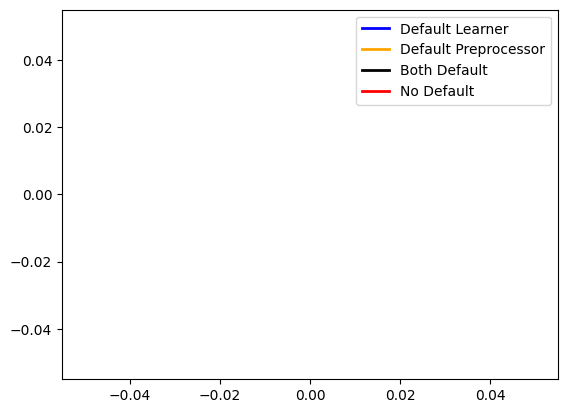

In [31]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

alpha = 0.1

# Plot Default Learner group
#for row in lcs2[default_learner == 1, :]:
#    plt.plot(row.T, color='blue', alpha=alpha)

# Plot Default Preprocessor group
#for row in lcs2[default_preprocessor == 1, :]:
#    plt.plot(row.T, color='orange', alpha=alpha)

# Plot No Default group
for row in lcs2[no_default == 1, :]:
    plt.plot(row.T, color='red', alpha=alpha)

# Plot Both Default group
for row in lcs2[default_both == 1, :]:
    plt.plot(row.T, color='black')

# Create opaque legend handles
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Default Learner'),
    Line2D([0], [0], color='orange', lw=2, label='Default Preprocessor'),
    Line2D([0], [0], color='black', lw=2, label='Both Default'),
    Line2D([0], [0], color='red', lw=2, label='No Default')
]

plt.legend(handles=legend_elements)
plt.show()


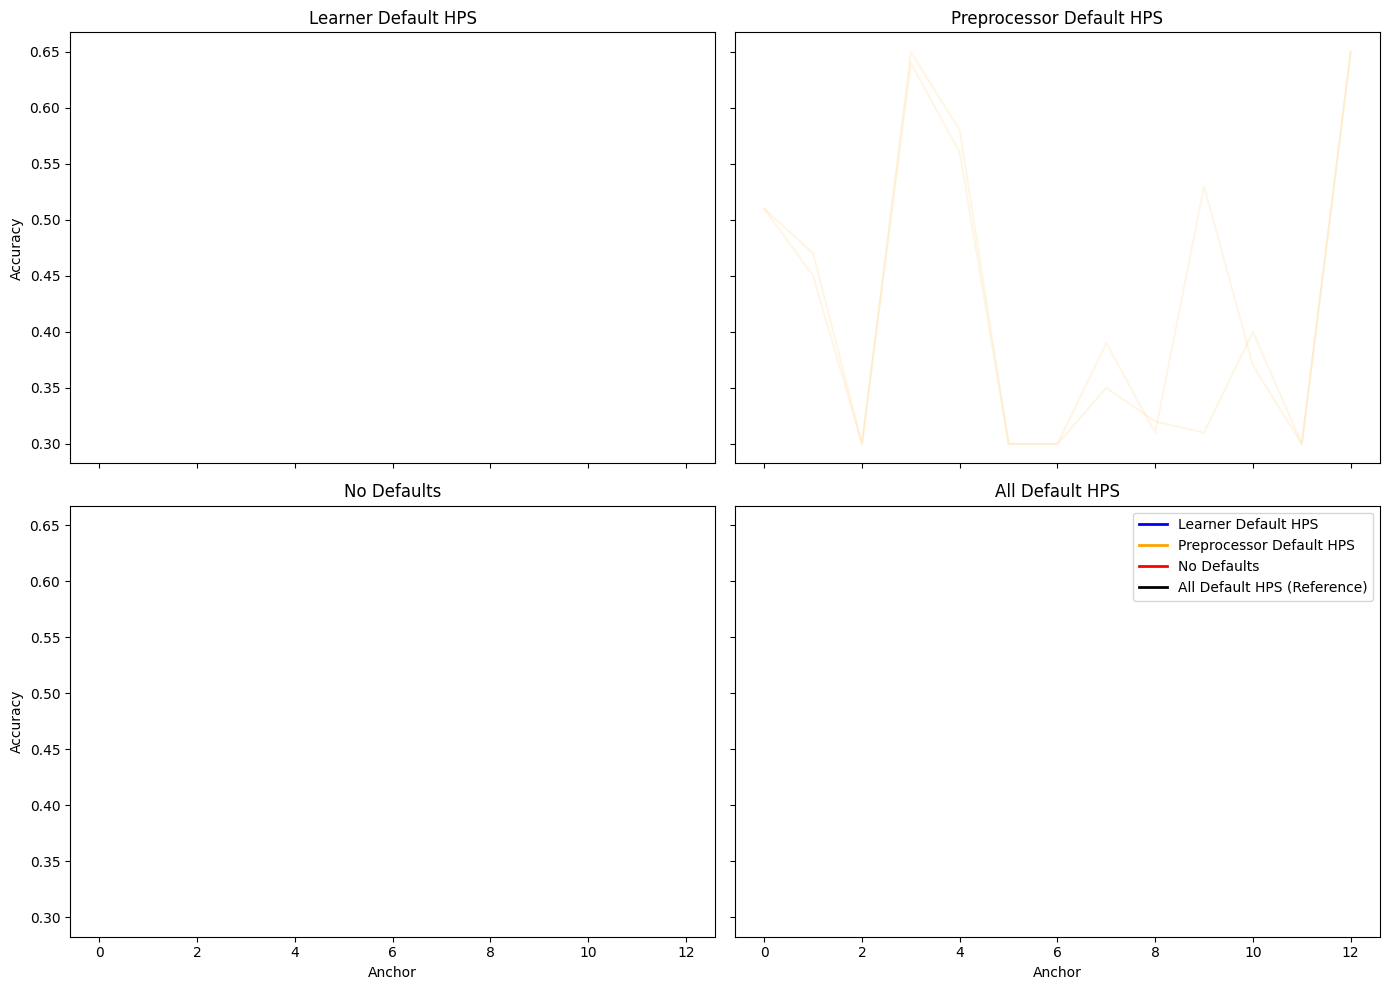

In [32]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

alpha = 0.1
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# Group settings with display labels
group_configs = [
    (lcs2[default_learner == 1, :], 'blue', 'Learner Default HPS', axs[0, 0]),
    (lcs2[default_preprocessor == 1, :], 'orange', 'Preprocessor Default HPS', axs[0, 1]),
    (lcs2[no_default == 1, :], 'red', 'No Defaults', axs[1, 0]),
    (lcs2[default_both == 1, :], 'purple', 'All Default HPS', axs[1, 1]),
]

# Always overlay "All Default HPS" in black
both_data = lcs2[default_both == 1, :]
both_color = 'black'
both_label = 'All Default HPS (Reference)'

# Plot each subplot
for data, color, title, ax in group_configs:
    for row in data:
        ax.plot(row.T, color=color, alpha=alpha)
    for row in both_data:
        ax.plot(row.T, color=both_color, alpha=1.0)
    ax.set_title(title)

# Set axis labels
for i in range(2):
    axs[1, i].set_xlabel("Anchor")
    axs[i, 0].set_ylabel("Accuracy")

# Add legend in bottom-right
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Learner Default HPS'),
    Line2D([0], [0], color='orange', lw=2, label='Preprocessor Default HPS'),
    Line2D([0], [0], color='red', lw=2, label='No Defaults'),
    Line2D([0], [0], color='black', lw=2, label='All Default HPS (Reference)'),
]
axs[1, 1].legend(handles=legend_elements, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()
